动态中断&静态中断

In [2]:
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.constants import START, END
from langgraph.graph import StateGraph, MessagesState
from typing import TypedDict, Required, Literal

from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display


class OverAllState(TypedDict):
    username: str
    age: int


def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名：")
    return {
        "username": username
    }


# builder
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)
# checkpoint
graph = builder.compile(checkpointer=InMemorySaver())
display(graph)

cfg = {
    "configurable": {
        "thread_id": "123"
    }
}

response = graph.invoke({}, config=cfg)
print(response)

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

{'__interrupt__': [Interrupt(value='请输入您的姓名：', id='3f24b6a420516cb456bd04f27a830b3f')]}


In [3]:
prompt = response['__interrupt__'][0].value
username = input(prompt)
resume_res = graph.invoke(Command(resume=username), config=cfg)
print(resume_res)

{'username': '11'}


### 多个并行中断

In [4]:
def node_b(state: OverAllState) -> OverAllState:
    age = interrupt("请输入您的年龄：")
    return {
        "age": age
    }


builder2 = StateGraph(state_schema=OverAllState)
builder2.add_node("node_b", node_b)
builder2.add_node("node_a", node_a)
builder2.add_edge(START, "node_b")
builder2.add_edge(START, "node_a")
builder2.add_edge("node_b", END)
builder2.add_edge("node_a", END)
graph2 = builder2.compile(checkpointer=InMemorySaver())
cfg2 = {
    "configurable": {
        "thread_id": "xiaoxu"
    }
}
response = graph2.invoke({}, config=cfg2)
print(response)
resume_map = {}
if response['__interrupt__']:
    for i in response['__interrupt__']:
        user_input = input(i.value)
        resume_map[i.id] = user_input

print(graph2.invoke(Command(resume=resume_map), config=cfg2))

{'__interrupt__': [Interrupt(value='请输入您的年龄：', id='c74a412dee3d6a67bbd710c8461fc9f9'), Interrupt(value='请输入您的姓名：', id='2c20ba4695e13136da7508562fba2023')]}
{'username': '11', 'age': '11'}


### 审批模式

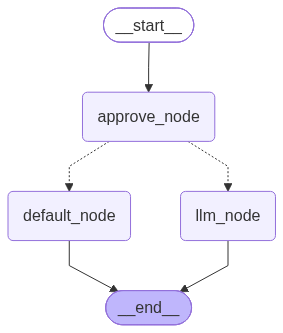

{'messages': [], 'topic': '月亮', '__interrupt__': [Interrupt(value='是否同意调用模型？(y/n)', id='aaee0ceb431fd50eb1a115a7248668d1')]}


In [5]:
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek

load_dotenv(override=True)
model = ChatDeepSeek(model="deepseek-flash", extra_body={
    "thinking": {
        "type": "disabled"
    }
})


# state
class CustomerState(MessagesState):
    topic: Required[str]
    poem: str
    is_approved: bool


def approve_node(state: CustomerState) -> Command[Literal["llm_node", "default_node"]]:
    is_approved = interrupt("是否同意调用模型？(y/n)")
    goto = "llm_node" if is_approved else "default_node"
    return Command(
        goto=goto,
        update={
            "is_approved": is_approved
        }
    )


def llm_node(state: CustomerState) -> CustomerState:
    topic = state["topic"]
    res = model.invoke([
        HumanMessage(content=f"帮我写一首关于{topic}的七言绝句，只需要诗句不需要赏析。")
    ])
    return {
        "messages": [res]
    }


def default_node(state: CustomerState) -> CustomerState:
    return {
        "messages": [AIMessage(content="请求被拒绝")]
    }


builder3 = StateGraph(state_schema=CustomerState)
builder3.add_node("approve_node", approve_node)
builder3.add_node("llm_node", llm_node)
builder3.add_node("default_node", default_node)

builder3.add_edge(START, "approve_node")
builder3.add_edge("llm_node", END)
builder3.add_edge("default_node", END)
cfg3 = {
    "configurable": {
        "thread_id": "abc"
    }
}
graph3 = builder3.compile(checkpointer=InMemorySaver())
display(graph3)
# 触发中断
response3 = graph3.invoke({"topic":"月亮"}, config=cfg3)
print(response3)

In [6]:
user_map = {}
for i in response3["__interrupt__"]:
    user_input = input(f"{i.value}").strip().lower() == 'y'
    user_map[i.id] = user_input

response4 = graph3.invoke(Command(resume=user_map), config=cfg3)
print(response4["messages"][-1])

content='请求被拒绝' additional_kwargs={} response_metadata={} id='f66b5895-a491-4a13-992c-8c94dde0a633' tool_calls=[] invalid_tool_calls=[]


### 静态中断

前面几个例子都是**动态中断**：在节点内部调用 `interrupt()`，由节点代码自己决定「我要在这里停下来问问人」。

**静态中断**则完全不动节点代码，而是在调用图的时候通过 `interrupt_before` / `interrupt_after` 参数指定节点名，让图在该节点执行**前 / 后**刹车：

```python
graph.invoke(input, config, interrupt_before=["step2"])   # step2 跑之前停
graph.invoke(input, config, interrupt_after=["step1"])    # step1 跑完之后停
```

两者的区别：

| | 动态中断 | 静态中断 |
|---|---|---|
| 触发方式 | 节点内调用 `interrupt()` | `invoke()` 传 `interrupt_before` / `interrupt_after` |
| 要改节点代码 | 需要 | 不需要 |
| 断点信息在哪 | 返回结果里有 `__interrupt__` | 返回结果里**没有** `__interrupt__`，用 `get_state(cfg).next` 看 |
| 怎么恢复 | `invoke(Command(resume=值), config)` | `invoke(None, config)` |
| 典型用途 | 收集用户输入、human-in-the-loop 审批 | 调试断点、逐步放行、人工审核后再改状态 |

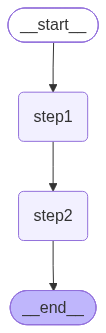

执行 step1
{'username': 'xiaoxu'}
StateSnapshot(values={'username': 'xiaoxu'}, next=('step2',), config={'configurable': {'thread_id': 'static-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bfde5-22ae-6d40-8001-71091856bc93'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-10-04T10:28:20.738566+00:00', parent_config={'configurable': {'thread_id': 'static-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bfde5-22a6-6fe6-8000-69c248ce7396'}}, tasks=(PregelTask(id='39a340ad-5468-3a46-5e65-31d58100125e', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())
('step2',)
{'username': 'xiaoxu'}


In [12]:
# 节点里没有任何 interrupt()，断点完全由 invoke 的参数决定


def step1(state: OverAllState) -> OverAllState:
    print("执行 step1")
    return {
        "username": "xiaoxu"
    }


def step2(state: OverAllState) -> OverAllState:
    print("执行 step2")
    return {
        "age": 18
    }


static_builder = StateGraph(state_schema=OverAllState)
static_builder.add_node("step1", step1)
static_builder.add_node("step2", step2)
static_builder.add_edge(START, "step1")
static_builder.add_edge("step1", "step2")
static_builder.add_edge("step2", END)
static_graph = static_builder.compile(checkpointer=InMemorySaver())
display(static_graph)

static_cfg = {
    "configurable": {
        "thread_id": "static-1"
    }
}

# 在 step2 执行前刹车：step1 已经跑完并落盘，step2 还没跑
res = static_graph.invoke({"username": "xiaoxu"}, config=static_cfg, interrupt_before=["step2"])
print(res)

# 静态中断的断点信息不在返回值里，要用 get_state 查
snap = static_graph.get_state(static_cfg)
print(snap)
print(snap.next)    # ('step2',) 下一个待执行的节点
print(snap.values)  # 已经产生的状态

In [8]:
# 恢复执行：input 传 None 即可从断点继续往下跑
print(static_graph.invoke(None, config=static_cfg))

执行 step2
{'username': 'xiaoxu', 'age': 18}


In [9]:
# interrupt_after：在节点执行「之后」停，适合「这一步已经生效了，先别急着做下一步」
after_cfg = {
    "configurable": {
        "thread_id": "static-2"
    }
}
print(static_graph.invoke({"username": "xiaoxu"}, config=after_cfg, interrupt_after=["step1"]))
print(static_graph.get_state(after_cfg).next)
print(static_graph.invoke(None, config=after_cfg))

执行 step1
{'username': 'xiaoxu'}
('step2',)
执行 step2
{'username': 'xiaoxu', 'age': 18}


In [10]:
# 断点处可以查看待执行任务，也可以在放行前人工修正状态
debug_cfg = {
    "configurable": {
        "thread_id": "static-3"
    }
}
static_graph.invoke({"username": "xiaoxu"}, config=debug_cfg, interrupt_before=["step2"])

# tasks 里能看到还卡着哪些节点，interrupts 为空说明是静态断点而非 interrupt() 动态断点
for task in static_graph.get_state(debug_cfg).tasks:
    print(task.name, task.interrupts)

# 人工审核后改掉状态，再放行，step2 读到的就是改过的值
static_graph.update_state(debug_cfg, {"username": "reviewer"})
print(static_graph.invoke(None, config=debug_cfg))

执行 step1
step2 ()
执行 step2
{'username': 'reviewer', 'age': 18}


In [11]:
# interrupt_before="*"：在每个节点执行前都停一次，可以逐节点单步调试
star_cfg = {
    "configurable": {
        "thread_id": "static-4"
    }
}
print(static_graph.invoke({"username": "xiaoxu"}, config=star_cfg, interrupt_before="*"))
print(static_graph.get_state(star_cfg).next)  # ('step1',) 一个节点都没跑
print(static_graph.invoke(None, config=star_cfg))

{'username': 'xiaoxu'}
('step1',)
执行 step1
执行 step2
{'username': 'xiaoxu', 'age': 18}


> ⚠️ **节点名写错不会报错**：`interrupt_before` / `interrupt_after` 传入的节点名如果拼错或压根不存在，LangGraph 不会抛异常，而是当作没有断点把整张图跑完，很容易误以为断点生效了。所以每次停下来后都建议用 `get_state(cfg).next` 确认确实停在了预期节点上。
>
> 另外 `stream()` 配合静态断点时，流里同样会出现一个 `{'__interrupt__': ()}` 的 chunk，可用来判断流是否因断点而终止。